# Performing warped GPR 

In [1]:
import pandas as pd
from astropy.time import Time

# Importing data
data = pd.read_csv(r"./Data/sind_subset1_3.txt", sep='\s',skip_blank_lines=True, header = None)
data.columns = ["JD", "sind"]
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')
data


C:\Users\Joey\AppData\Local\Temp\ipykernel_50780\299919939.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/sind_subset1_3.txt", sep='\s',skip_blank_lines=True, header = None)


,JD,sind,year
datetime,,,
1966-09-02 08:34:04.799986,2439370.857,0.173873,1966.669013
1966-09-03 08:13:55.199989,2439371.843,0.175041,1966.671713
1966-09-04 07:55:12.000006,2439372.830,0.174457,1966.674415
1966-09-24 08:16:48.000018,2439392.845,0.175236,1966.729213
1966-09-25 07:56:38.399980,2439393.831,0.175918,1966.731912
...,...,...,...
1991-08-26 16:59:31.200009,2448495.208,0.181948,1991.650125
1991-08-28 16:59:31.200009,2448497.208,0.177421,1991.655600
1991-08-29 16:59:31.200009,2448498.208,0.179252,1991.658338


In [2]:
# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.7, valid_split=0.2):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()

train_df, valid_df, test_df = split_df(data)
print(train_df.shape, valid_df.shape, test_df.shape)

(1184, 3) (338, 3) (169, 3)


In [3]:
import matplotlib.pyplot as plt

def plot_predictions(trainingset, validset, results):
    fig,ax = plt.subplots(figsize = (20,5))
    ax.plot(trainingset['year'], trainingset['sind'], color = 'blue', label = 'Training')
    ax.plot(validset['year'], validset['sind'], color = 'orange', label = 'Actual')
    results_time = results.index.to_series().apply(lambda d: d.year + (d.timetuple().tm_yday - 1) / 365.25)
    ax.plot(results_time, results['forecast'], color = 'green', label = 'Predictions')
    ax.fill_between(results_time, results['lower'], results['upper'], color = 'green', alpha = 0.2, label = 'Uncertainties')
    plt.legend()
    plt.show()

- Now implement the GP over the S-index
- The S-index is strictly positive so must use warping
- Need to extend to include the uncertainties of our datapoints.

In [4]:
import celerite2
import numpy as np
from celerite2 import terms

train_mean = train_df["sind"].mean()
train_std  = train_df["sind"].std()

# quasii-periodic kernel: RotationTerm = two SHO terms
initial_params = {
    "sigma":  train_std,  # amplitude near observed variability
    "period": 11,         # solar cycle
    "Q0":     0.5,
    "dQ":     0.01,
    "f":      0.5,
}


True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
sigma=0.00654  period=13.729 yr  Q0=0.000  dQ=0.0022  f=0.115


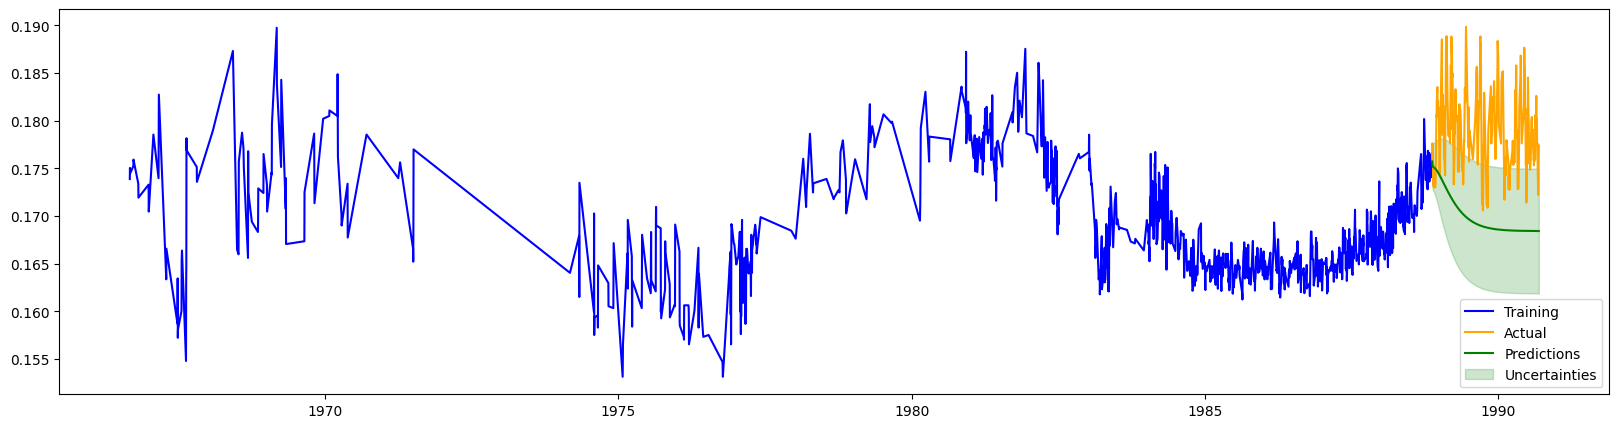

In [5]:
from scipy.optimize import minimize

def set_params(log_params, gp):
    vals = np.exp(log_params)
    gp.kernel = terms.RotationTerm(sigma=vals[0], period=vals[1], Q0=vals[2], dQ=vals[3], f=vals[4]) # have to replace the kernel otherwise the values don't change
    return gp

def NLL(log_params, gp, y):
    gp = set_params(log_params, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

initial_guess = np.log([
    initial_params["sigma"],
    initial_params["period"],
    initial_params["Q0"],
    initial_params["dQ"],
    initial_params["f"],
])


kernel = terms.RotationTerm(
    sigma=initial_params['sigma'],
    period=initial_params['period'], 
    Q0=initial_params['Q0'], 
    dQ=initial_params['dQ'], 
    f=initial_params['f'])
gp = celerite2.GaussianProcess(kernel, mean=train_mean)
gp.compute(train_df['year'], yerr=1e-3)

gp_res = minimize(NLL, initial_guess, args=(gp, train_df["sind"].to_numpy()), method="L-BFGS-B")
gp = set_params(gp_res.x, gp)
gp.recompute()

best = np.exp(gp_res.x)
print(gp_res.success, gp_res.message)
print(f"sigma={best[0]:.5f}  period={best[1]:.3f} yr  Q0={best[2]:.3f}  dQ={best[3]:.4f}  f={best[4]:.3f}")


# now predict
t_pred = valid_df['year']
mu, cov = gp.predict(train_df['sind'], t = t_pred, return_var = True)
sigma = np.sqrt(cov)

# plot predictions
results = pd.DataFrame({
    'forecast' : mu,
    'lower'    : mu - sigma,
    'upper'    : mu + sigma,
}, index=valid_df.index)

plot_predictions(
    trainingset=train_df,
    validset=valid_df,
    results=results
                 )


LS Comment: There are two types of periodicity in the data. One long one short (rotation period). So cannot fit monotone.

- Interpreting the results a little:
    - sigma=0.00654 
        - Not significant given range of data.
    - period=13.729 yr  
        - More or less in the range we expect. 
        - Would be refined with more cycles of data.
    - Q0=0.000  
        - Quality factor of 0.
        - Means heavily damped: the kernel has no memory.
        - WHY?!?!?
    - dQ=0.0022  
        - This means the other quality factor is also very low.
        - The kernel is basically constant. WHY?!
    - f=0.115
        - Most of the power is in the primary term with Q0 = 0.
        - Would be sensible since I don't there there is a strong half-harmonic cycle.

- The reason we use these rotation terms is because they approximate a decaying exp times a periodic kernel: nearer times should have greater effect.

- This is possibly an adequate baseline but compared to the WGPR paper the performance is not great. 
- WGPR paper Fig 2 uses fewer cycles of data and achieves better results.  
- I can see no need for warping here because the data need not satisfy positivity constraints explicitly as the data lives sufficiently far from the zero point.
- Things to try:
    - Recreating the WGPR paper's genetic algorithm training procedure in full.
    - Refining the mean estimate: perhaps the mean varies with time.
    - Quasi-periodic is a short term matter. Perhaps introduce a SHOTerm as well? 
    - Perhaps need to work with bigger dataset and include the error terms properly.
    - Maybe add a linear term to address drift? 
    - Try with a regular periodic kernel?

True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
sigma=0.00654  period=13.729 yr  Q0=0.000  dQ=0.0022  f=0.115


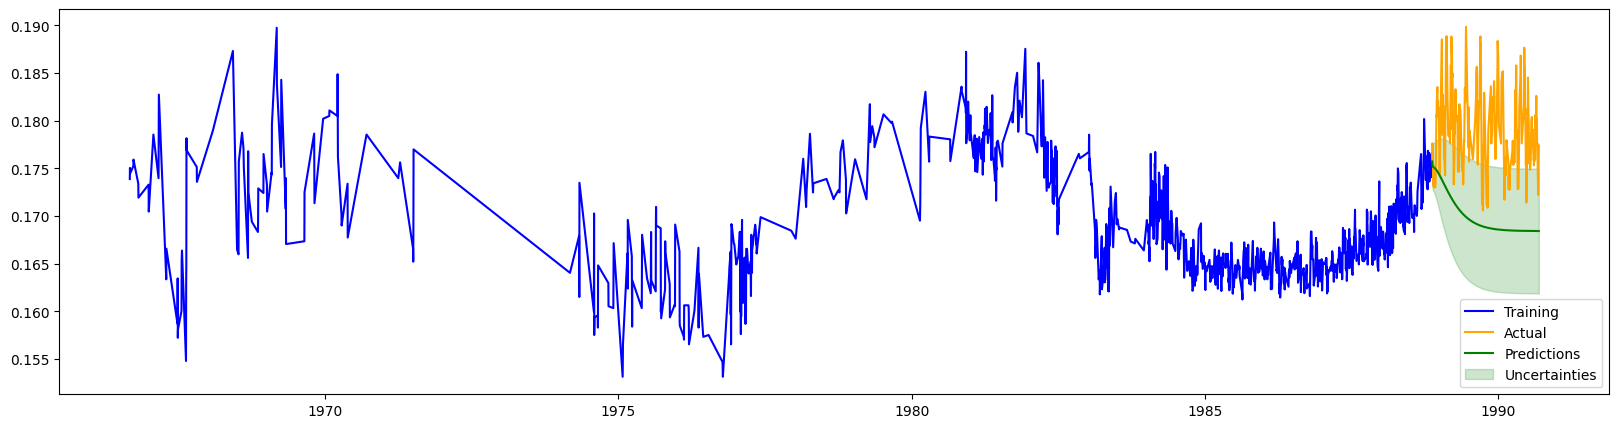

In [6]:
# Adding SHOTerm to the kernel

kernel = terms.RotationTerm(
    sigma=initial_params['sigma'],
    period=initial_params['period'], 
    Q0=initial_params['Q0'], 
    dQ=initial_params['dQ'], 
    f=initial_params['f'])
kernel += terms.SHOTerm(
                        S0=1.0,
                        Q=2.5, 
                        w0=0.2
)
gp = celerite2.GaussianProcess(kernel, mean=train_mean)
gp.compute(train_df['year'], yerr=1e-3)

gp_res = minimize(NLL, initial_guess, args=(gp, train_df["sind"].to_numpy()), method="L-BFGS-B")
gp = set_params(gp_res.x, gp)
gp.recompute()

best = np.exp(gp_res.x)
print(gp_res.success, gp_res.message)
print(f"sigma={best[0]:.5f}  period={best[1]:.3f} yr  Q0={best[2]:.3f}  dQ={best[3]:.4f}  f={best[4]:.3f}")

# now predict
t_pred = valid_df['year']
mu_lt, cov_lt = gp.predict(train_df['sind'], t = t_pred, return_var = True) # lt indicates long term component from SHOTerm
sigma_lt = np.sqrt(cov_lt)

# plot the lt results

results_lt = pd.DataFrame({
    'forecast' : mu_lt,
    'lower'    : mu_lt - sigma_lt,
    'upper'    : mu_lt + sigma_lt,
}, index=valid_df.index)

plot_predictions(
    trainingset=train_df,
    validset=valid_df,
    results=results_lt
                 )


LS Comment: Try giving a better bound and prior; this should work

- SHO Term models the aperiodic background:
    - Grander variations beyond the 11 year cycle. The Sun goes through centuries-long episodes of suppressed activity (Maunder Minimum ~1645–1715) or enhanced activity. 
- Rotation Term handles the actual 11 year variations.
    - Q controls how quickly the kernel loses its phase.
    - A perfectly periodic signal would have infinite Q. But our signal the cycles very in length.
    - Q controls how much neighbouring lengths are allowed to vary.

True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
RotationTerm: sigma=0.00658  period=10.455 yr  Q0=0.000  dQ=0.0038  f=0.113
SHOTerm:      sigma=0.00500  rho=100.000 yr  Q=0.2000


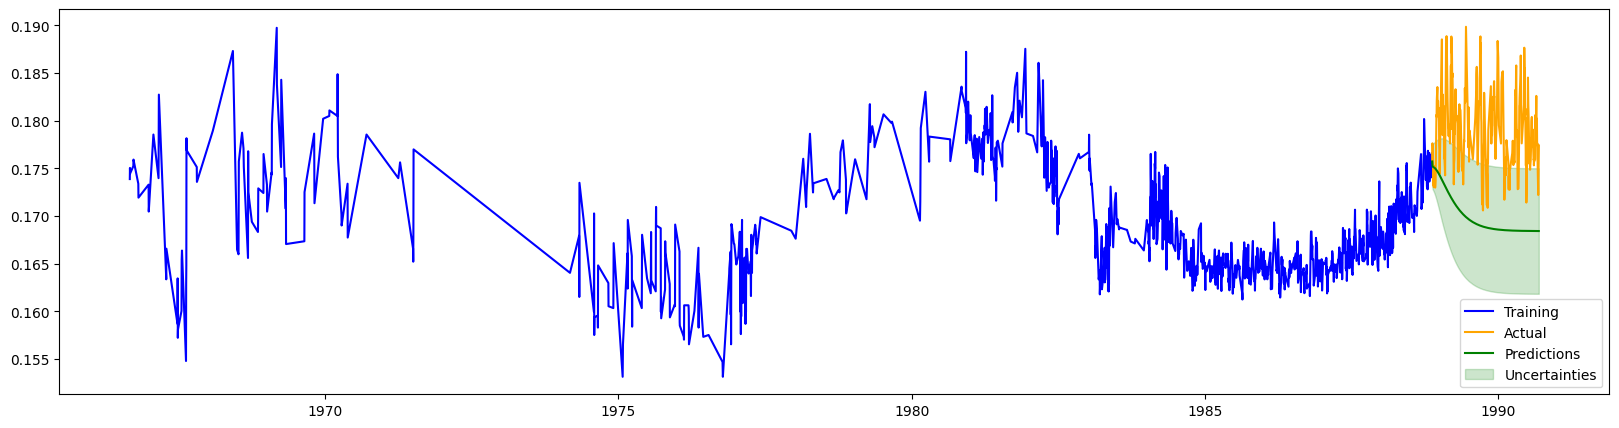

In [10]:
train_mean = train_df["sind"].mean()
train_std  = train_df["sind"].std()

# quasii-periodic kernel: RotationTerm = two SHO terms
initial_params = {
    "rot_sigma": train_std, # amplitude near observed variability
    "rot_period": 11, # solar cycle
    "rot_Q0": 1, # the quality factor of the decaying oscillation; how fast periods can change from one cycle to the next. q < 0.5 is overdamped > is underdamped
                            # choose 1 to be overdamped: plausible that the cycle is decently coherent in the longer term
    "rot_dQ": 0.01, # the difference in quality factors between the two oscillations in the rotation term. The dQ one has double the frequency
                            # this controls the phase coherence; large dq is more asymmetric
                            # we do not expect a strong P/2 signal as the assymetry is not too strong
    "rot_f": 0.1,  # the power fraction from the main term 
    "sho_sigma": 0.005,  # set using total peak-to-peak drift/2
    "sho_rho": 100, # this is the period
    "sho_Q": 0.2 # natural frequency of the oscillator
                        # this lives in the overdamped threshold giving a smooth monotone
}

initial_guess = np.log([
    initial_params["rot_sigma"],
    initial_params["rot_period"],
    initial_params["rot_Q0"],
    initial_params["rot_dQ"],
    initial_params["rot_f"],
    initial_params["sho_sigma"],
    initial_params["sho_rho"],
    initial_params["sho_Q"]
])


# Adding SHOTerm to the kernel
kernel = terms.RotationTerm( # Asymmetric decaying oscillation in lag-space
    sigma=initial_params['rot_sigma'],
    period=initial_params['rot_period'], 
    Q0=initial_params['rot_Q0'], 
    dQ=initial_params['rot_dQ'], 
    f=initial_params['rot_f'])
kernel += terms.SHOTerm( # This looks like a decaying oscillation
                        sigma=initial_params['sho_sigma'],
                        Q=initial_params['sho_Q'], 
                        rho=initial_params['sho_rho']
)
gp = celerite2.GaussianProcess(kernel, mean=train_mean)
gp.compute(train_df['year'], yerr=1e-3)

gp_res = minimize(NLL, initial_guess, args=(gp, train_df["sind"].to_numpy()), method="L-BFGS-B")
gp = set_params(gp_res.x, gp)
gp.recompute()

best = np.exp(gp_res.x)
print(gp_res.success, gp_res.message)
print(f"RotationTerm: sigma={best[0]:.5f}  period={best[1]:.3f} yr  Q0={best[2]:.3f}  dQ={best[3]:.4f}  f={best[4]:.3f}")
print(f"SHOTerm:      sigma={best[5]:.5f}  rho={best[6]:.3f} yr  Q={best[7]:.4f}")

# now predict
t_pred = valid_df['year']
mu_lt, cov_lt = gp.predict(train_df['sind'], t = t_pred, return_var = True) # lt indicates long term component from SHOTerm
sigma_lt = np.sqrt(cov_lt)

# plot the lt results

results_lt = pd.DataFrame({
    'forecast' : mu_lt,
    'lower'    : mu_lt - sigma_lt,
    'upper'    : mu_lt + sigma_lt,
}, index=valid_df.index)

plot_predictions(
    trainingset=train_df,
    validset=valid_df,
    results=results_lt
                 )
